In [73]:
# compare the taiwanese and white global networks
# Numbers of total interactions of each one
# Number of genes, number of miRNAs, number of total nodes
# intersection between genes, miRNAs and overall
# DIFFERENTIAL EXPRESSION?
# TOTAL NUMBER OF DEGS/DEmiRNAs
# NUMBER OF DEGS/MIRNAs in NETWORKS
# LOG2FC CORRELATION OF TOTAL DEGS/DEMIRNAS
# LOG2FC CORRELATION OF DEGS/DEMIRNAS IN NETWORKS

library(ggVennDiagram)
library(ggplot2)
library(miRBaseConverter)

In [74]:
setwd("/home/seba/github_repos/crc_weighted_network/")

In [75]:
# Compare the lists of GENEs from each cohort
taiwanese_expr <- readRDS("taiwanese_cohort/rna_pooled/datExpr_clean.rds")
white_expr <- readRDS("cohort_white/rna_pooled/datExpr_clean.rds")

ncol(taiwanese_expr)
ncol(white_expr)

[1] 19208

[1] 18842

In [76]:
# Comapre the lists of miRNAs from each cohort
taiwanese_mirna <- readRDS("taiwanese_cohort/mirna_pooled/datExpr_clean.rds")
white_mirna <- readRDS("cohort_white/mirna_pooled/datExpr_clean.rds")

ncol(taiwanese_mirna)
ncol(white_mirna)

[1] 1929

[1] 1149

In [77]:
# Remove after the . in the colnames
colnames(taiwanese_expr) <- gsub("\\.\\d+$", "", colnames(taiwanese_expr))
colnames(white_expr) <- gsub("\\.\\d+$", "", colnames(white_expr))

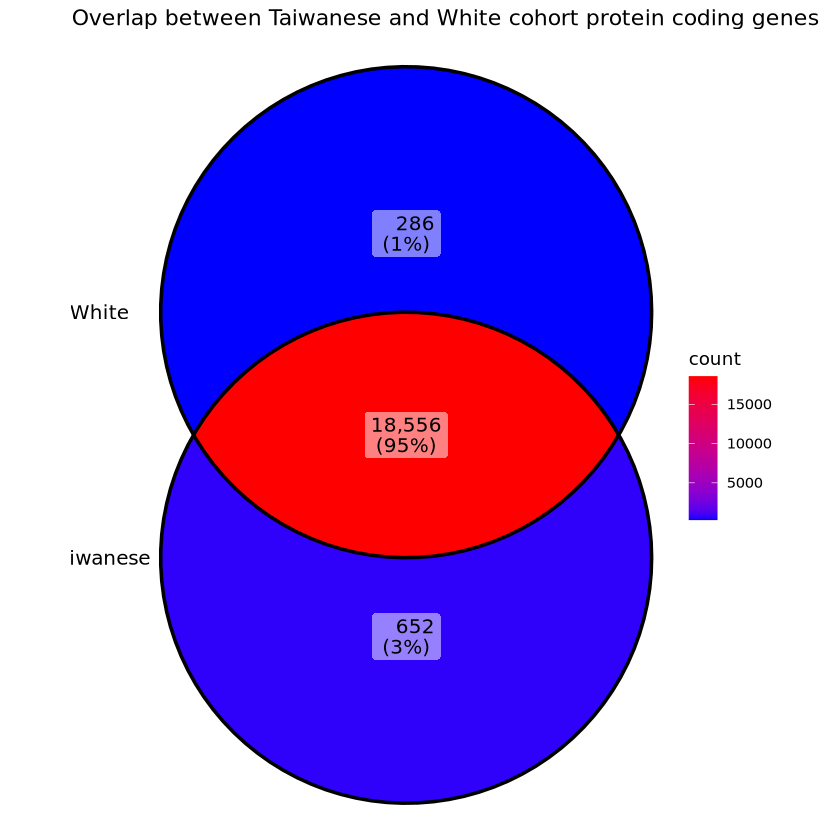

In [78]:
# Venn diagram of gene lists
taiwanese_genes <- colnames(taiwanese_expr)
white_genes <- colnames(white_expr)
listado <- list(Taiwanese = taiwanese_genes,
                 White = white_genes)
ggVennDiagram(listado)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort protein coding genes")


In [115]:
taiwanese_mirnas <- readRDS("taiwanese_cohort/mirna_pooled/datExpr_clean.rds")
white_mirnas <- readRDS("cohort_white/mirna_pooled/datExpr_clean.rds")

# replace hsa-mir with hsa-miR in white mirnas
colnames(white_mirnas) <- gsub("hsa-mir", "hsa-miR", colnames(white_mirnas))

# pass taiwanese mirnas from name to ID
new_taiwanese <- miRNA_NameToAccession(colnames(taiwanese_mirnas), version = "v22")

new_white <- miRNAVersionConvert(colnames(white_mirnas), targetVersion = "v22", exact=TRUE)

********************************************


The multiple matched miRNAs are list below: 




     original                   Version v22                 Accession
1 hsa-miR-340 hsa-miR-340-3p&hsa-miR-340-5p MIMAT0000750&MIMAT0004692
2 hsa-miR-34b hsa-miR-34b-5p&hsa-miR-34b-3p MIMAT0000685&MIMAT0004676
3 hsa-miR-425 hsa-miR-425-3p&hsa-miR-425-5p MIMAT0001343&MIMAT0003393
4 hsa-miR-488 hsa-miR-488-5p&hsa-miR-488-3p MIMAT0002804&MIMAT0004763
5 hsa-miR-493 hsa-miR-493-5p&hsa-miR-493-3p MIMAT0002813&MIMAT0003161
6 hsa-miR-589 hsa-miR-589-3p&hsa-miR-589-5p MIMAT0003256&MIMAT0004799
7 hsa-miR-616 hsa-miR-616-5p&hsa-miR-616-3p MIMAT0003284&MIMAT0004805
8 hsa-miR-624 hsa-miR-624-5p&hsa-miR-624-3p MIMAT0003293&MIMAT0004807
9 hsa-miR-629 hsa-miR-629-3p&hsa-miR-629-5p MIMAT0003298&MIMAT0004810


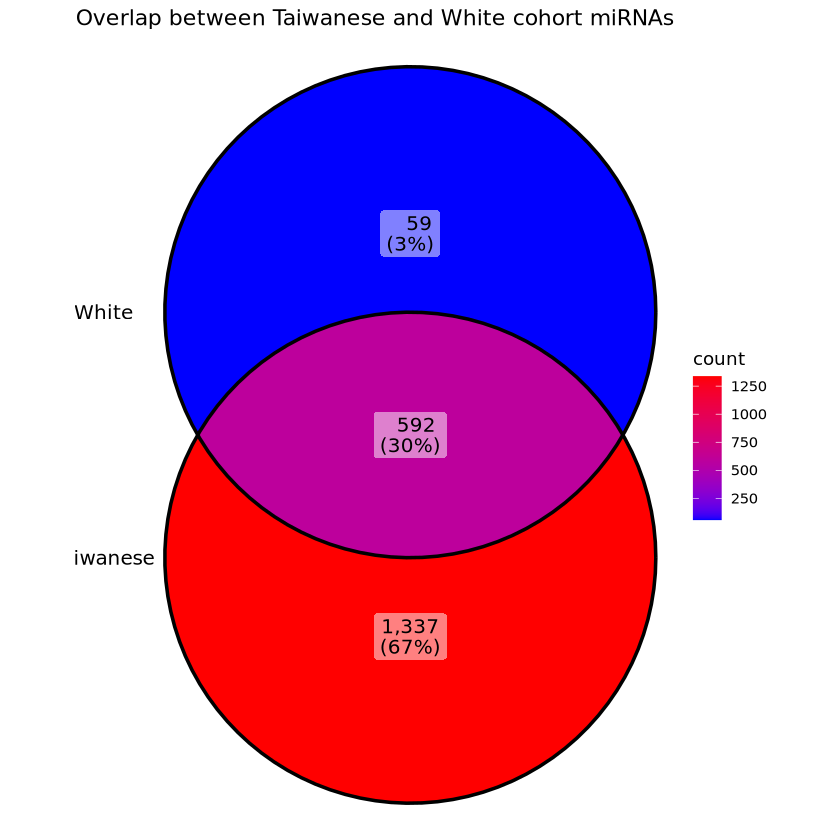

In [ ]:
listado_mirna <- list(Taiwanese = new_taiwanese$Accession,
                      White = new_white$Accession)

# OJO
# USAR NAMES VS NAMES O ACCESSIONS VS ACCESSIONS DA LO MISMO EN ESTE CASO DE MIRNAS

ggVennDiagram(listado_mirna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort miRNAs")

In [3]:
# Load networks
taiwanese_path <- "taiwanese_cohort/count_matrices_by_geneid/ENCORI_filtered_edges_selected_modules_TAIWAN.tsv"
white_path <- "cohort_white/count_matrices_white_byFILENAME/ENCORI_filtered_edges_selected_modules_WHITE.tsv"

taiwanese_net <- read.table(taiwanese_path, sep="\t", header=TRUE)
white_net <- read.table(white_path, sep="\t", header=TRUE)

In [4]:
# also load differential expression table
de_taiwan_rna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_RNA_results.tsv"
de_taiwan_mirna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_miRNA_results.tsv"

de_white_rna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_RNA_results.tsv"
de_white_mirna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_miRNA_results.tsv"

taiwan_dernas <- read.table(de_taiwan_rna_path, header=TRUE, sep="\t", row.names=1)
taiwan_demirnas <- read.table(de_taiwan_mirna_path, header=TRUE, sep="\t", row.names=1)

white_dernas <- read.table(de_white_rna_path, header=TRUE, sep="\t", row.names=1)
white_demirnas <- read.table(de_white_mirna_path, header=TRUE, sep="\t", row.names=1)

In [5]:
# How many DEGs from TAIWAN
table(taiwan_dernas$Category)
# How many DEmiRNAs from TAIWAN
table(taiwan_demirnas$Category)

# How many DEGs from TAIWAN
table(white_dernas$Category)
# How many DEmiRNAs from TAIWAN
table(white_demirnas$Category)


Down-regulated   Up-regulated 
          2358           2904 


 Down-regulated Not significant    Up-regulated 
            107            1268             292 


Down-regulated   Up-regulated 
          2257           2246 


 Down-regulated Not significant    Up-regulated 
            196             697             122 